# 7. Model Comparison

All six models trained on the identical split (2016–2022) and scored on the
identical held-out years (2023–2025). This notebook collects their saved results,
builds the comparison table, and works out *where* each one fails rather than only
how much.

**Run notebooks 01–06 first** — this reads the JSON files they write to
`models/results/`.

## Setup

Colors are assigned to models in fixed order and never re-sorted, so a model keeps
its color across every chart even when the ranking changes. The palette is
colorblind-safe (validated for deuteranopia and tritanopia separation).

In [1]:
import sys, json
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_all_results, load_split, RESULTS, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

# color follows the model, never its rank
MODEL_ORDER = ['Linear Regression', 'Random Forest', 'Gradient Boosting',
               'SVR', 'KNN', 'Neural Network']
PALETTE = ['#005A8C', '#D55E00', '#009E73', '#8E4EC6', '#B07800', '#4C9BD1']
COLOR = dict(zip(MODEL_ORDER, PALETTE))

INK, MUTED = '#1a1a1a', '#6b6b6b'

results = load_all_results()
print(f'loaded {len(results)} model results')
print(f'test period: {meta["test_range"][0]} -> {meta["test_range"][1]}  ({meta["n_test"]} days)')

loaded 6 model results
test period: 2023-01-01 -> 2025-12-30  (1095 days)


## Reference baselines

An R² of 0.78 sounds good, but good compared to what? Two trivial predictors set
the floor:

- **Training mean** — predict 89.4 (the 2016–2022 average) every single day.
- **Seasonal climatology** — predict the historical average AQI for that calendar
  day-of-year. This is the honest baseline, because it captures the seasonal cycle
  *without using any weather information at all*. Anything a weather model earns
  above this line is the actual contribution of weather.

In [2]:
from model_utils import metrics

# baseline 1: constant training mean
mean_pred = np.full(len(y_test), y_train.mean())

# baseline 2: day-of-year climatology learned from the training years only
train_doy = pd.DataFrame({'doy': meta['train_dates'].dt.dayofyear, 'aqi': y_train.values})
clim = train_doy.groupby('doy')['aqi'].mean()
clim_smooth = (clim.reindex(range(1, 367))
                   .interpolate()
                   .rolling(15, center=True, min_periods=1).mean())   # smooth the day-to-day noise
clim_pred = meta['test_dates'].dt.dayofyear.map(clim_smooth).values

baselines = pd.DataFrame([
    {'Model': 'Baseline: training mean',  **{k: v for k, v in metrics(y_test, mean_pred).items()}},
    {'Model': 'Baseline: day-of-year climatology', **{k: v for k, v in metrics(y_test, clim_pred).items()}},
])
print(baselines.round(3).to_string(index=False))

                            Model   rmse    mae     r2   mape  within_10
          Baseline: training mean 40.422 33.230 -0.003 42.767     13.881
Baseline: day-of-year climatology 31.764 24.507  0.381 31.331     28.676


Climatology alone reaches R² 0.38 — so a good chunk of what any model "explains"
is just knowing that summer is worse than winter. The weather features have to earn
their keep above **that** line, not above zero.

## The comparison table

Sorted by test RMSE, best first. Every column is computed on the same 1,095 held-out
days.

| column | meaning |
|---|---|
| **Test RMSE** | typical error in AQI points, penalizing large misses heavily — the headline metric |
| **Test MAE** | typical error, treating all misses equally |
| **Test R²** | share of test variance explained |
| **Test MAPE %** | average error as a percentage of the true value |
| **Within 10 AQI %** | share of days called within 10 points — AQI categories are ~50 wide, so this approximates "got the category right" |
| **Overfit Gap** | test RMSE − train RMSE; how much worse the model does on data it has not seen |

In [3]:
table = results.drop(columns=['Notes'])
display_cols = ['Model', 'Test RMSE', 'Test MAE', 'Test R2', 'Test MAPE %',
                'Within 10 AQI %', 'Train RMSE', 'Train R2', 'Overfit Gap']

print(table[display_cols].round(3).to_string(index=False))
print()
print('For reference:')
print(f'  day-of-year climatology (no weather): RMSE {metrics(y_test, clim_pred)["rmse"]:.3f}, '
      f'R2 {metrics(y_test, clim_pred)["r2"]:.3f}')
print(f'  training mean (constant):             RMSE {metrics(y_test, mean_pred)["rmse"]:.3f}, '
      f'R2 {metrics(y_test, mean_pred)["r2"]:.3f}')

            Model  Test RMSE  Test MAE  Test R2  Test MAPE %  Within 10 AQI %  Train RMSE  Train R2  Overfit Gap
              SVR     18.851    13.565    0.782       15.822           48.950      17.246     0.783        1.605
   Neural Network     19.054    13.992    0.777       16.629           48.493      16.893     0.792        2.161
Gradient Boosting     19.484    13.842    0.767       15.818           50.137       8.735     0.944       10.749
    Random Forest     20.275    14.674    0.748       17.200           47.489       8.763     0.944       11.512
              KNN     21.887    15.712    0.706       18.684           45.662       0.000     1.000       21.887
Linear Regression     24.007    17.879    0.646       21.067           38.265      24.551     0.560       -0.544

For reference:
  day-of-year climatology (no weather): RMSE 31.764, R2 0.381
  training mean (constant):             RMSE 40.422, R2 -0.003


A caveat that the table cannot express on its own: **KNN's Train RMSE of 0.000 and
its Overfit Gap are artifacts.** It was tuned to `weights='distance'`, and a
training point is its own nearest neighbour at distance zero, so it reproduces every
training label exactly by construction. Read only its test columns.

## Ranking by test error

One series, so no legend is needed — the axis names the models. Values are labeled
directly rather than forcing a read against gridlines, and the two baselines are
drawn as reference lines.

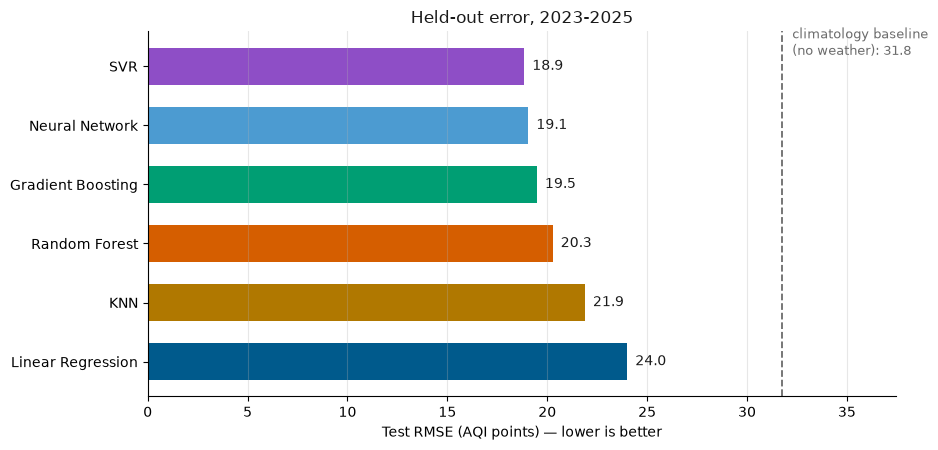

In [4]:
with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    r = results.sort_values('Test RMSE', ascending=False)
    clim_rmse = metrics(y_test, clim_pred)['rmse']

    bars = ax.barh(r['Model'], r['Test RMSE'],
                   color=[COLOR[m] for m in r['Model']], height=0.62)
    for bar, val in zip(bars, r['Test RMSE']):
        ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2, f'{val:.1f}',
                va='center', fontsize=10, color=INK)

    # the line has to sit inside the axis limits or it silently vanishes
    ax.set_xlim(0, max(r['Test RMSE'].max(), clim_rmse) * 1.18)
    ax.axvline(clim_rmse, color=MUTED, ls='--', lw=1.3)
    ax.text(clim_rmse + 0.5, len(r) - 0.6,
            f'climatology baseline\n(no weather): {clim_rmse:.1f}',
            ha='left', va='center', fontsize=9, color=MUTED)

    ax.set_xlabel('Test RMSE (AQI points) — lower is better')
    ax.set_title('Held-out error, 2023-2025', fontsize=12, color=INK)
    ax.grid(axis='y', visible=False)
    plt.tight_layout(); plt.show()

## Which models can be trusted on data they have not seen

Train and test RMSE side by side. A short bar next to a tall one means the model
learned the training years far better than it learned the problem.

KNN is excluded — its zero training error is the structural artifact described
above and would make the chart misleading.

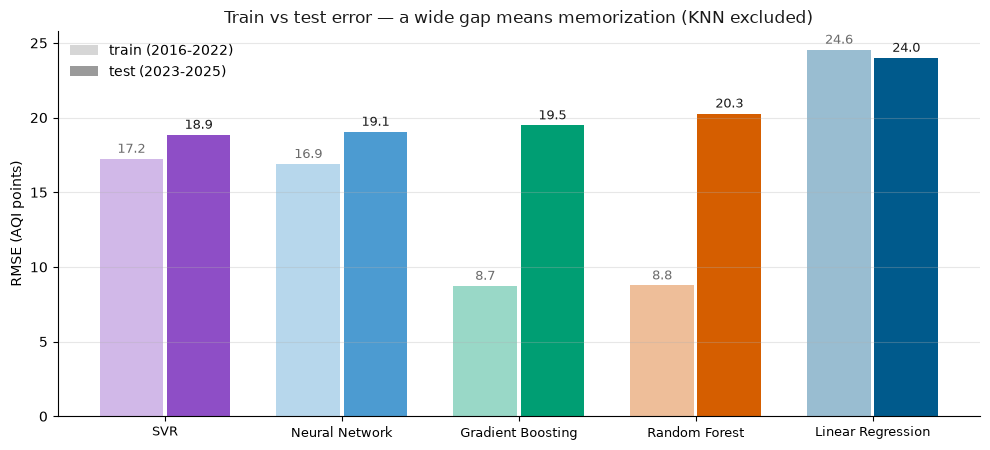

In [5]:
from matplotlib.patches import Patch

with plt.rc_context(PLOT_STYLE):
    r = results[results.Model != 'KNN'].sort_values('Test RMSE')
    x = np.arange(len(r)); w = 0.36

    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.bar(x - w/2 - 0.01, r['Train RMSE'], w, color=[COLOR[m] for m in r['Model']], alpha=0.4)
    ax.bar(x + w/2 + 0.01, r['Test RMSE'],  w, color=[COLOR[m] for m in r['Model']])

    for xi, (tr, te) in enumerate(zip(r['Train RMSE'], r['Test RMSE'])):
        ax.text(xi - w/2 - 0.01, tr + 0.4, f'{tr:.1f}', ha='center', fontsize=9, color=MUTED)
        ax.text(xi + w/2 + 0.01, te + 0.4, f'{te:.1f}', ha='center', fontsize=9, color=INK)

    # neutral proxy swatches: color already encodes the model, so the legend
    # must encode only the train/test distinction
    ax.legend(handles=[Patch(facecolor='#9a9a9a', alpha=0.4, label='train (2016-2022)'),
                       Patch(facecolor='#9a9a9a', label='test (2023-2025)')],
              frameon=False)

    ax.set_xticks(x); ax.set_xticklabels(r['Model'], fontsize=9)
    ax.set_ylabel('RMSE (AQI points)')
    ax.set_title('Train vs test error — a wide gap means memorization (KNN excluded)',
                 fontsize=12, color=INK)
    ax.grid(axis='x', visible=False)
    plt.tight_layout(); plt.show()

The split is stark. SVR and the neural network barely degrade out of sample; the
two tree ensembles more than double their error. All four land in a similar test
band, but they get there very differently — and the two with small gaps are the ones
whose training-time estimates you could actually believe on new data.

## Where the errors actually are

Aggregate RMSE hides the thing that matters most for air quality. A model can look
excellent while being useless precisely on the days that trigger health advisories.

This breaks mean absolute error down by the *actual* AQI band, using the EPA's own
categories. Six series, so identity comes from both the legend and the fixed
colors.

In [6]:
preds = {}
for m in MODEL_ORDER:
    slug = m.lower().replace(' ', '_')
    preds[m] = np.load(RESULTS / f'{slug}_test_pred.npy')

BANDS = [(0, 50, 'Good\n0-50'), (50, 100, 'Moderate\n51-100'),
         (100, 150, 'USG\n101-150'), (150, 300, 'Unhealthy\n151+')]

yt = np.asarray(y_test, dtype=float)
rows = []
for lo, hi, label in BANDS:
    mask = (yt > lo) & (yt <= hi)
    for m in MODEL_ORDER:
        rows.append({'band': label, 'n': int(mask.sum()), 'Model': m,
                     'mae': np.mean(np.abs(yt[mask] - preds[m][mask])),
                     'bias': np.mean(preds[m][mask] - yt[mask])})
band_df = pd.DataFrame(rows)

print('Test days per band:')
print(band_df.groupby('band', sort=False)['n'].first().to_string())
print('\nMean absolute error by band (AQI points):')
print(band_df.pivot(index='Model', columns='band', values='mae')
             .reindex(MODEL_ORDER)[[b[2] for b in BANDS]].round(2).to_string())

Test days per band:
band
Good\n0-50          123
Moderate\n51-100    655
USG\n101-150        195
Unhealthy\n151+     122

Mean absolute error by band (AQI points):
band               Good\n0-50  Moderate\n51-100  USG\n101-150  Unhealthy\n151+
Model                                                                         
Linear Regression       10.90             14.16         16.18            47.58
Random Forest           10.90             10.59         17.57            35.80
Gradient Boosting        8.77              9.85         18.72            32.61
SVR                      9.55              9.85         17.06            31.97
KNN                     11.69             11.82         16.74            39.03
Neural Network           9.14             11.24         16.46            29.70


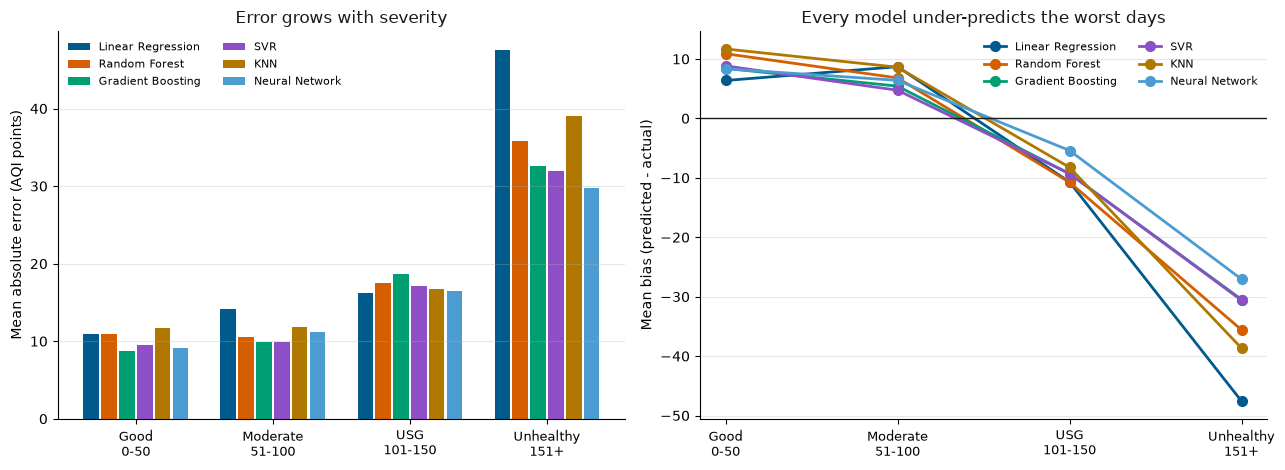

In [7]:
with plt.rc_context(PLOT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    labels = [b[2] for b in BANDS]
    x = np.arange(len(labels)); w = 0.13

    for i, m in enumerate(MODEL_ORDER):
        sub = band_df[band_df.Model == m].set_index('band').reindex(labels)
        axes[0].bar(x + (i - 2.5) * w, sub['mae'], w * 0.88, color=COLOR[m], label=m)
        axes[1].plot(x, sub['bias'], 'o-', color=COLOR[m], label=m, lw=2, ms=7)

    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
    axes[0].set_ylabel('Mean absolute error (AQI points)')
    axes[0].set_title('Error grows with severity', fontsize=12, color=INK)
    axes[0].legend(frameon=False, fontsize=8, ncol=2)
    axes[0].grid(axis='x', visible=False)

    axes[1].axhline(0, color=INK, lw=1)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9)
    axes[1].set_ylabel('Mean bias (predicted - actual)')
    axes[1].set_title('Every model under-predicts the worst days', fontsize=12, color=INK)
    axes[1].legend(frameon=False, fontsize=8, ncol=2)
    axes[1].grid(axis='x', visible=False)

    plt.tight_layout(); plt.show()

This is the most important chart in the project.

Every one of the six models is **biased downward on the unhealthy days and upward on
the clean ones** — all six lines slope the same way and cross zero in roughly the
same place. That is regression to the mean, and it is not a bug in any single model:
it is what least-squares fitting does when the predictors are only partly
informative. Squared-error loss is minimized by hedging toward the middle, so the
extremes get shaved.

The practical consequence is that a model reporting RMSE ≈ 19 will still call a
genuinely unhealthy day as merely moderate a meaningful share of the time.

## How the best model tracks the actual series

The ranking chart says SVR wins; this shows what winning looks like day by day.

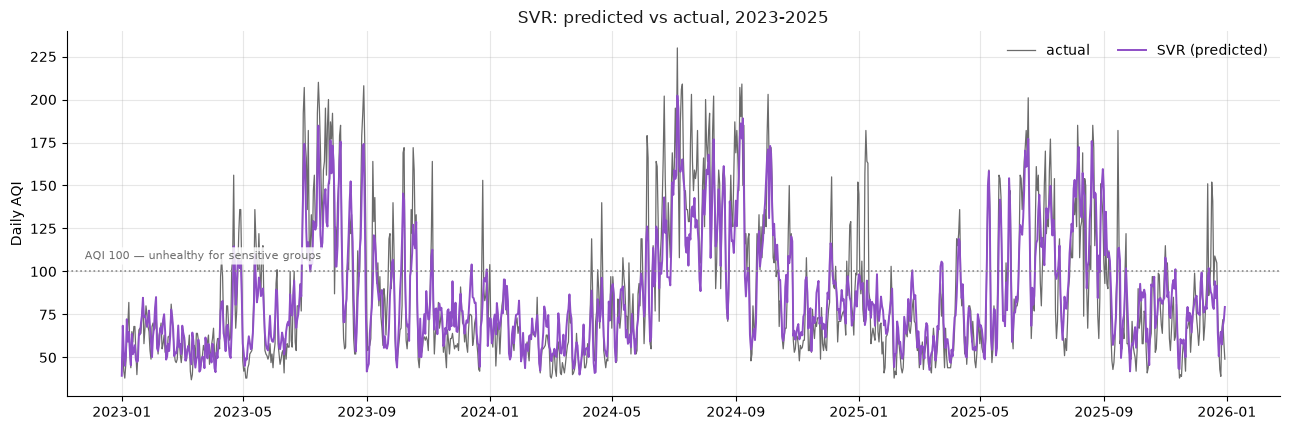

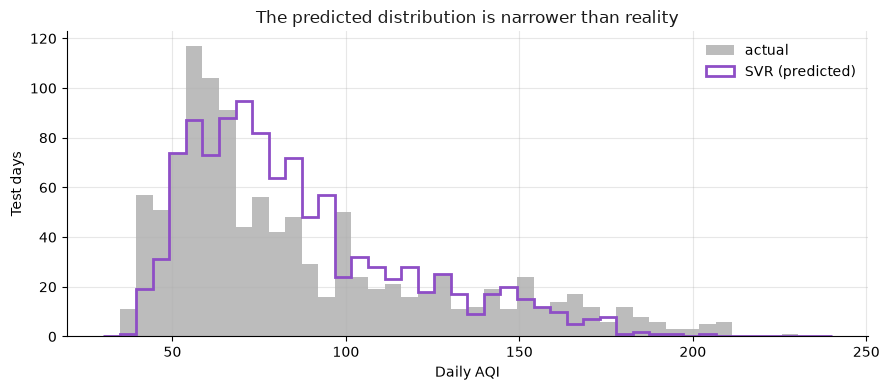

In [8]:
best_name = results.iloc[0]['Model']
best_pred = preds[best_name]
dates = meta['test_dates']

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(13, 4.4))
    ax.plot(dates, yt, lw=0.9, color=MUTED, label='actual')
    ax.plot(dates, best_pred, lw=1.4, color=COLOR[best_name], label=f'{best_name} (predicted)')

    # reference line labeled clear of the data, not on top of it
    ax.axhline(100, color='#8a8a8a', ls=':', lw=1.2)
    ax.annotate('AQI 100 — unhealthy for sensitive groups',
                xy=(0.015, 100), xycoords=('axes fraction', 'data'),
                xytext=(0, 7), textcoords='offset points',
                ha='left', va='bottom', fontsize=8, color=MUTED,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))

    ax.set_ylabel('Daily AQI')
    ax.set_title(f'{best_name}: predicted vs actual, 2023-2025', fontsize=12, color=INK)
    ax.legend(frameon=False, loc='upper right', ncol=2)
    plt.tight_layout(); plt.show()

    # the same story as a distribution: does the model reproduce the spread?
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(30, 240, 45)
    ax.hist(yt, bins=bins, color=MUTED, alpha=0.45, label='actual')
    ax.hist(best_pred, bins=bins, histtype='step', lw=2,
            color=COLOR[best_name], label=f'{best_name} (predicted)')
    ax.set_xlabel('Daily AQI'); ax.set_ylabel('Test days')
    ax.set_title('The predicted distribution is narrower than reality', fontsize=12, color=INK)
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

The seasonal rhythm is captured well — summer peaks and winter troughs land in the
right places. The failure is amplitude: the predicted distribution is visibly
narrower than the actual one, with the right-hand tail cut short. The model knows
*when* bad days happen and consistently underestimates *how* bad.

## Verdict

**SVR is the best model on this data** — test RMSE 18.9, R² 0.782 — but the margin
over the neural network (19.1) and gradient boosting (19.5) is small enough that it
should not be over-read. The more defensible claim is that four models cluster
between 18.9 and 20.3 and are, for practical purposes, tied.

What separates SVR is *how* it gets there. Its overfit gap is +1.6 against +10.7 and
+11.5 for the tree ensembles, so its training-time performance is an honest estimate
of its field performance. If this model were deployed, SVR is the one whose behavior
on new data is most predictable.

Three findings hold across all six models:

1. **Weather explains roughly 78% of the variance in LA's daily AQI** — and about
   half of that is the seasonal cycle, which day-of-year climatology recovers on its
   own (R² 0.38, RMSE 31.8) with no weather data at all. The genuine weather contribution is the
   gap between those two numbers, which is real but smaller than the headline
   suggests.
2. **Temperature dominates every model.** `t2m_max` is the top feature by permutation
   importance for both tree models, and by a wide margin in the boosted one. LA's AQI
   is an ozone story, and ozone needs heat.
3. **Every model under-predicts unhealthy days.** This is a property of squared-error
   loss with partly-informative predictors, not a tuning failure, and it is the single
   biggest obstacle to using any of these as a public-health warning system.

**Where extra flexibility stopped paying.** The neural network — the most expressive
model here — needed the strongest regularization in its grid to reach second place,
and KNN's memorization bought it nothing. At ~2,500 training days, the ceiling is set
by the information in the features, not by model capacity.

### What would most likely improve on this

- **Add the missing physics.** Boundary-layer height, subsidence inversion strength,
  and sea-breeze indicators are the actual mechanism trapping pollution over LA, and
  none of them are in the current four MERRA-2 variables. This is the highest-value
  change available.
- **Give the model persistence.** Yesterday's *AQI* is not currently a feature; only
  yesterday's weather is. Adding an AQI lag would likely produce the largest single
  jump in accuracy — though it changes the scientific question from "what does weather
  explain?" to "what is tomorrow's AQI?", so it belongs in a separate framing.
- **Attack the extremes directly.** Weighting high-AQI days more heavily in the loss,
  or reframing as classification over EPA categories, targets the failure that matters
  most rather than the average error.
- **Model pollutants separately.** The target is a max over five pollutants with
  different drivers; ozone and PM2.5 models combined afterward would let each learn its
  own chemistry.